
## Salud Mental en el Entorno Laboral — ¿Qué tan grande es el problema y por qué no se habla de él?

**Visualización de Datos**  
**Herramienta:** Python (pandas, matplotlib, seaborn)  
**Dataset:** Mental Health in Tech Survey — 292,364 registros

---
## a) Contexto Comunicacional

**Propósito del análisis:** construir visualizaciones con Python para pasar de una exploración inicial de datos a una comunicación para una audiencia específica.

**Contexto del caso**
En la actualidad, la salud mental se ha vuelto un tema cada vez más relevante, incluso dentro del mundo laboral, ya que los problemas mentales no solo afectan a las personas sino que también pueden llegar a tener un gran impacto dentro de las empresas ya que situaciones como la presión constante, las largas jornadas, inseguridad laboral o ambientes laborales poco saludables pueden generar estrés, ansiedad y otros problemas emocionales que alteran el bienestar y el rendimiento de los trabajadores.

Según la Organización Mundial de la Salud (OMS, 2022), la depresión y la ansiedad provocan la pérdida de millones de días laborales cada año, ya que esta situación aumenta el ausentismo, disminución de productividad y desempeño laboral, evidenciando que los problemas de salud mental no se tratan solamente de una situación personal, sino que también influye en el mundo laboral y social de las personas.

Para este análisis se usará un dataset que proviene de una encuesta internacional sobre salud mental. La encuesta se aplicó a trabajadores de varios países y de diferentes industrias, sobre todo del sector tecnológico y corporativo, la cual recoge datos sobre los niveles de estrés, la búsqueda de tratamiento psicológico, el historial familiar, los hábitos y el grado de comodidad que sienten las personas al hablar de salud mental en su trabajo.


### **Audiencia objetivo**
**Dirección de Recursos Humanos / Gerencia de Bienestar Organizacional**  
Personas encargadas de diseñar políticas de bienestar, beneficios de salud y cultura organizacional.

**¿Qué necesita saber o decidir esta audiencia?**  
Si existe suficiente evidencia para justificar la creación o ampliación de un programa de salud mental organizacional.

### Pregunta guía del proyecto
> *¿El estrés y los problemas de salud mental son un problema real y extendido en el entorno laboral, o es un tema que solo afecta a una minoría?*


### Gran Idea (Big Idea)
> *"El estrés mental es un problema real y extendido en el entorno laboral — afecta a casi uno de cada dos trabajadores — pero el estigma es tan grande que menos del 3% estaría dispuesto a mencionarlo en una entrevista de trabajo. Sin una política activa de salud mental, el problema permanece invisible y sin atención."*

### Estructura narrativa
Las tres visualizaciones responden preguntas conectadas que construyen la historia de forma progresiva:

| # | Pregunta | Variable central | Gráfico |
|---|---|---|---|
| 1 | ¿Quiénes experimentan más estrés? | Growing_Stress por `Occupation` | Barras horizontales |
| 2 | ¿Quién busca ayuda y por qué? | treatment según family_history | Barras horizontales |
| 3 | ¿Por qué el problema sigue sin atenderse? | mental_health_interview | Barras horizontales |


### Glosario de variables principales

| Variable | Descripción | Valores posibles |
|---|---|---|
| Growing_Stress | ¿El trabajador siente que su estrés está aumentando? | Yes / Maybe / No |
| treatment | ¿Ha buscado tratamiento para un problema de salud mental? | Yes / No |
| family_history | ¿Tiene antecedentes familiares de problemas de salud mental? | Yes / No |
| mental_health_interview | ¿Mencionaría un problema de salud mental en una entrevista laboral? | Yes / Maybe / No |
| Occupation | Tipo de ocupación del encuestado | Corporate / Student / Housewife / Business / Others |
| Coping_Struggles | ¿Tiene dificultad para sobrellevar sus problemas de salud mental? | Yes / No |
| care_options | ¿Conoce las opciones de atención en salud mental disponibles? | Yes / No / Not sure |
| Mood_Swings | Nivel de cambios de humor reportados | Low / Medium / High |

---
## Lo que necesita un buen gráfico — 8 Principios aplicados en este proyecto

> Un buen gráfico no solo muestra datos. **Comunica rápido, resalta lo importante y ayuda a tomar decisiones.**

| # | Principio | Cómo se aplica en este proyecto |
|---|---|---|
| 1 | **Mensaje claro** | Cada título es un hallazgo, no un nombre de variable. Ej: *"El 79% no hablaría de salud mental en una entrevista"* en lugar de *"mental_health_interview"* |
| 2 | **Eliminar desorden visual** | Se retiran bordes superiores/derechos, cuadrículas pesadas, fondos grises, leyendas redundantes y colores innecesarios |
| 3 | **Resaltar lo importante** | Atributo preatentivo: **un solo color de énfasis (naranja)** sobre un fondo gris neutro. El cerebro lo detecta en milisegundos |
| 4 | **Jerarquía visual** | 1º título/hallazgo → 2º barra destacada en naranja → 3º etiqueta con % → 4º anotación con conclusión |
| 5 | **Colores con propósito** | Naranja = alerta/hallazgo, Azul = informativo, Gris = contexto. Cada color tiene un rol único y consistente |
| 6 | **Gráfico correcto** | Barras horizontales para comparar categorías. Se eliminó el gráfico de pastel (difícil de comparar ángulos) en favor de barras con etiquetas directas |
| 7 | **Contar una historia** | Narrativa Problema → Exploración → Hallazgo → Recomendación. Los 3 gráficos responden 3 preguntas conectadas |
| 8 | **Pensar en la audiencia** | Diseñado para un gerente de RRHH: KPIs grandes, conclusión visible, sin análisis estadístico complejo |

---
## Setup — Librerías y configuración visual

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
# PALETA DE COLORES — Principios de uso del color aplicados
# ══════════════════════════════════════════════════════════════════════════
#
# ① USO MODERADO   → Solo un color de énfasis; el resto es gris neutro.
# ② USO CONSISTENTE → El mismo color SIEMPRE representa lo mismo en TODAS las gráficas.
#                     Naranja = hallazgo/alerta | Azul = informativo | Gris = contexto
# ③ DALTONISMO      → Paleta de Paul Tol: naranja en lugar de rojo,
#                     verde-azulado en lugar de verde puro.
#                     Nunca rojo + verde juntos.
# ④ CUIDADO DEL TONO → Azul oscuro (#0077BB) = valor mayor / más crítico
#                      Azul claro (#77BBDD) = valor menor / menos crítico
# ⑤ COLOR MARCA     → Un único azul institucional #0077BB se usa en todos
#                     los elementos principales del proyecto.
#
COLOR_PRIMARY  = '#0077BB'  # azul institucional   — dato informativo
COLOR_LIGHT    = '#77BBDD'  # azul claro (tono)    — valor menor / comparación
COLOR_ALERT    = '#EE7733'  # naranja              — hallazgo importante / alerta
COLOR_NEUTRAL  = '#BBBBBB'  # gris                 — datos de contexto / fondo
COLOR_TEAL     = '#009988'  # verde-azulado        — dato positivo (daltonismo-safe)

# Estilo base
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 120,
})

print('Librerías cargadas correctamente ✓')
print()
print('Paleta activa (compatible con daltonismo):')
print(f'  COLOR_PRIMARY  = {COLOR_PRIMARY}  → azul institucional')
print(f'  COLOR_LIGHT    = {COLOR_LIGHT}  → azul claro (tono menor)')
print(f'  COLOR_ALERT    = {COLOR_ALERT}  → naranja (reemplaza rojo)')
print(f'  COLOR_NEUTRAL  = {COLOR_NEUTRAL}  → gris neutro')
print(f'  COLOR_TEAL     = {COLOR_TEAL}  → verde-azulado (reemplaza verde puro)')

Librerías cargadas correctamente ✓

Paleta activa (compatible con daltonismo):
  COLOR_PRIMARY  = #0077BB  → azul institucional
  COLOR_LIGHT    = #77BBDD  → azul claro (tono menor)
  COLOR_ALERT    = #EE7733  → naranja (reemplaza rojo)
  COLOR_NEUTRAL  = #BBBBBB  → gris neutro
  COLOR_TEAL     = #009988  → verde-azulado (reemplaza verde puro)


---
## b) Exploración inicial de los datos

---
## Uso del Color — 5 Principios Aplicados

> Este proyecto aplica conscientemente las cinco lecciones de uso del color en visualización de datos.

| # | Principio | Decisión en este proyecto |
|---|---|---|
| ① | **Uso moderado** | Solo el dato más relevante recibe el color naranja de énfasis; el resto de barras es gris neutro |
| ② | **Uso consistente** | Naranja (`#EE7733`) = hallazgo/alerta **en todas las gráficas**, sin excepción |
| ③ | **Daltonismo** | Paleta de Paul Tol: naranja en lugar de rojo, verde-azulado en lugar de verde puro. Nunca rojo + verde juntos |
| ④ | **Cuidado del tono** | Azul oscuro = valor mayor / más crítico; azul claro = valor menor. El tono comunica magnitud |
| ⑤ | **Color de marca** | El azul institucional `#0077BB` es el color base de todos los paneles y elementos de identidad |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df=pd.read_csv('/content/drive/MyDrive/IA/visualizacion_datos_franco_keyal/Mental Health Dataset.csv')

print(f"{'Registros':<25}: {df.shape[0]:>10,}")
print(f"{'Variables':<25}: {df.shape[1]:>10}")
print(f"\nColumnas: {df.columns.tolist()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Registros                :    292,364
Variables                :         17

Columnas: ['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']


In [ ]:
# ── Tipos de datos y valores faltantes ────────────────────────────────────
info = pd.DataFrame({
    'Tipo'           : df.dtypes.astype(str),
    'Valores_únicos' : df.nunique(),
    'Nulos'          : df.isnull().sum(),
    '% Nulos'        : (df.isnull().sum() / len(df) * 100).round(2)
})
# La columna self_employed tiene blancos, los tratamos como 'No especificado'
df['self_employed'] = df['self_employed'].replace('', 'No especificado')
print(info.to_string())

                           Tipo  Valores_únicos  Nulos  % Nulos
Timestamp                object             580      0     0.00
Gender                   object               2      0     0.00
Country                  object              35      0     0.00
Occupation               object               5      0     0.00
self_employed            object               2   5202     1.78
family_history           object               2      0     0.00
treatment                object               2      0     0.00
Days_Indoors             object               5      0     0.00
Growing_Stress           object               3      0     0.00
Changes_Habits           object               3      0     0.00
Mental_Health_History    object               3      0     0.00
Mood_Swings              object               3      0     0.00
Coping_Struggles         object               2      0     0.00
Work_Interest            object               3      0     0.00
Social_Weakness          object         

In [ ]:
# ── Variables seleccionadas y primeras observaciones ──────────────────────
vars_clave = ['Gender','Occupation','treatment','Growing_Stress',
              'family_history','mental_health_interview',
              'care_options','Coping_Struggles','Mood_Swings']

print("=" * 55)
print("DISTRIBUCIONES DE VARIABLES CLAVE (%)")
print("=" * 55)
for col in vars_clave:
    print(f"\n► {col}")
    dist = (df[col].value_counts(normalize=True)*100).round(1)
    for val, pct in dist.items():
        bar = '█' * int(pct / 2)
        print(f"  {str(val):<22} {pct:>5.1f}%  {bar}")

DISTRIBUCIONES DE VARIABLES CLAVE (%)

► Gender
  Male                    82.0%  █████████████████████████████████████████
  Female                  18.0%  █████████

► Occupation
  Housewife               22.7%  ███████████
  Student                 21.1%  ██████████
  Corporate               20.9%  ██████████
  Others                  18.1%  █████████
  Business                17.2%  ████████

► treatment
  Yes                     50.5%  █████████████████████████
  No                      49.5%  ████████████████████████

► Growing_Stress
  Maybe                   34.2%  █████████████████
  Yes                     34.1%  █████████████████
  No                      31.7%  ███████████████

► family_history
  No                      60.5%  ██████████████████████████████
  Yes                     39.5%  ███████████████████

► mental_health_interview
  No                      79.4%  ███████████████████████████████████████
  Maybe                   17.6%  ████████
  Yes                     

In [ ]:
# ── Hallazgos de la exploración ───────────────────────────────────────────
n = len(df)
pct_treatment    = (df['treatment']=='Yes').mean()*100
pct_stress_yes   = (df['Growing_Stress']=='Yes').mean()*100
pct_stress_maybe = (df['Growing_Stress']=='Maybe').mean()*100
pct_interview_no = (df['mental_health_interview']=='No').mean()*100
pct_interview_yes= (df['mental_health_interview']=='Yes').mean()*100
pct_coping_no    = (df['Coping_Struggles']=='Yes').mean()*100

print("RESUMEN EJECUTIVO DE LA EXPLORACIÓN")
print("─" * 50)
print(f"  Total encuestados          : {n:,}")
print(f"  Buscan tratamiento         : {pct_treatment:.1f}%")
print(f"  Estrés creciente (Sí)      : {pct_stress_yes:.1f}%")
print(f"  Estrés creciente (Tal vez) : {pct_stress_maybe:.1f}%")
print(f"  → Potencialmente estresados: {pct_stress_yes+pct_stress_maybe:.1f}%")
print(f"  Dificultad para sobrellevar: {pct_coping_no:.1f}%")
print(f"  NO hablarían en entrevista : {pct_interview_no:.1f}%")
print(f"  SÍ hablarían en entrevista : {pct_interview_yes:.1f}%  ← ALERTA")

RESUMEN EJECUTIVO DE LA EXPLORACIÓN
──────────────────────────────────────────────────
  Total encuestados          : 292,364
  Buscan tratamiento         : 50.5%
  Estrés creciente (Sí)      : 34.1%
  Estrés creciente (Tal vez) : 34.2%
  → Potencialmente estresados: 68.3%
  Dificultad para sobrellevar: 47.2%
  NO hablarían en entrevista : 79.4%
  SÍ hablarían en entrevista : 2.9%  ← ALERTA


---
## c) Visualizaciones Iniciales
> Estas gráficas son un primer intento exploratorio con la configuración por defecto de matplotlib. Son funcionales pero presentan varias limitaciones de diseño que se mejorarán en la siguiente sección.

► Versión inicial 1: estrés por ocupación


Text(0.5, 16.466666666666665, 'Ocupación')

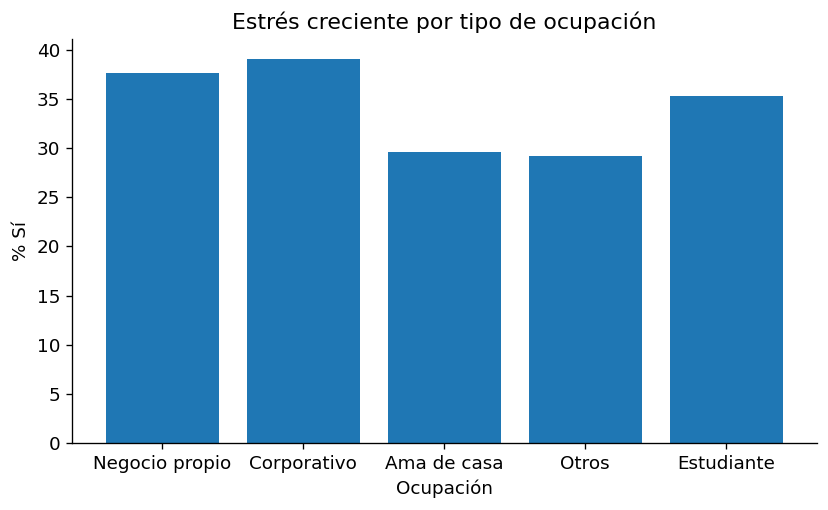

In [ ]:
# ── GRÁFICA INICIAL 1: Estrés creciente por ocupación ─────────────────────
# Versión básica — salida directa de matplotlib sin ajustes de diseño

# Mapeo de ocupaciones al español
ocup_es = {
    'Corporate' : 'Corporativo',
    'Student'   : 'Estudiante',
    'Housewife' : 'Ama de casa',
    'Business'  : 'Negocio propio',
    'Others'    : 'Otros'
}

stress_occ = df.groupby('Occupation')['Growing_Stress'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
stress_occ.columns = ['Ocupación', 'Pct_Estres']

stress_occ['Ocupación'] = stress_occ['Ocupación'].map(ocup_es)
print("► Versión inicial 1: estrés por ocupación")

plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
plt.tight_layout()

ax.bar(stress_occ['Ocupación'], stress_occ['Pct_Estres'])
ax.set_ylabel('% Sí')

ax.set_title('Estrés creciente por tipo de ocupación')
ax.set_xlabel('Ocupación')

► Versión inicial 2: tratamiento vs historial familiar


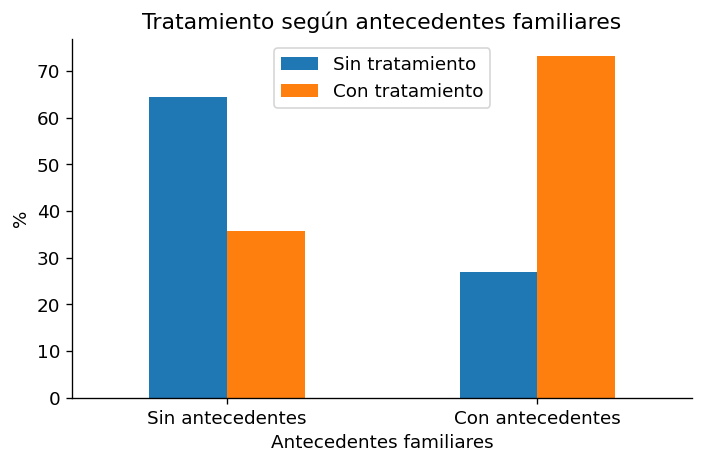

In [ ]:
# ── GRÁFICA INICIAL 2: Tratamiento según historial familiar ───────────────
# Versión básica — tabla cruzada con gráfico de barras agrupadas por defecto

treat_fam = pd.crosstab(
    df['family_history'],
    df['treatment'],
    normalize='index'
) * 100
# Renombrar columnas y filas al español
treat_fam.columns.name = None
treat_fam = treat_fam.rename(columns={'No': 'Sin tratamiento', 'Yes': 'Con tratamiento'})
treat_fam.index = treat_fam.index.map({'No': 'Sin antecedentes', 'Yes': 'Con antecedentes'})

fig, ax = plt.subplots(figsize=(6, 4))
treat_fam.plot(kind='bar', ax=ax)
ax.set_title('Tratamiento según antecedentes familiares')
ax.set_xlabel('Antecedentes familiares')
ax.set_ylabel('%')

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
print("► Versión inicial 2: tratamiento vs historial familiar")

plt.tight_layout()
plt.show()

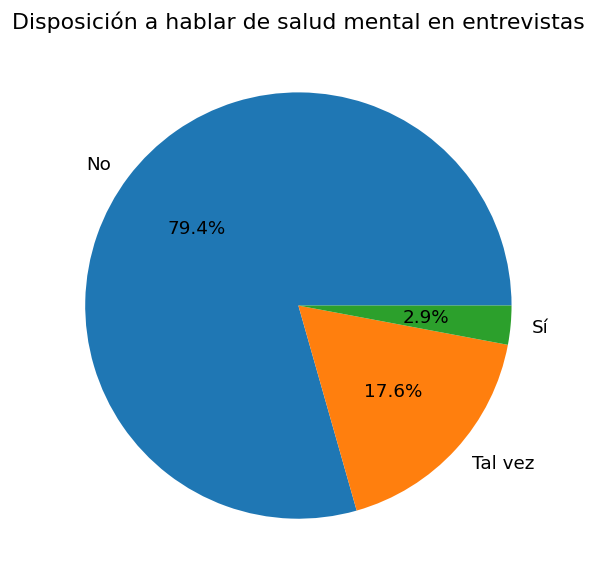

► Versión inicial 3: disposición a hablar en entrevistas


In [ ]:
# ── GRÁFICA INICIAL 3: Disposición a hablar en entrevistas ────────────────
# Versión básica — gráfico de pastel con configuración por defecto
interview_counts = df['mental_health_interview'].value_counts()
# Etiquetas en español para el pastel
entrevista_es = {'Yes': 'Sí', 'Maybe': 'Tal vez', 'No': 'No'}
interview_labels = [entrevista_es.get(l, l) for l in interview_counts.index]
fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(interview_counts, labels=interview_labels, autopct='%1.1f%%')
ax.set_title('Disposición a hablar de salud mental en entrevistas')
plt.tight_layout()
plt.show()
print("► Versión inicial 3: disposición a hablar en entrevistas")

---
## d) Iteración y Mejora Visual

Cada gráfica se presenta en **versión inicial** (izquierda) y **versión mejorada** (derecha).  
Los 8 principios de un buen gráfico se evidencian así:

### Gráfica 1 — Estrés por ocupación
| Principio | Versión inicial | Versión mejorada |
|---|---|---|
| **① Mensaje claro** | Título: *"Growing_Stress by Occupation"* (nombre de variable) | Título: *"Los trabajadores independientes concentran el mayor estrés"* (hallazgo) |
| **② Eliminar desorden** | Bordes en los 4 lados, sin orden | Sin bordes laterales, barras ordenadas por magnitud |
| **③ Resaltar lo importante** | Todas las barras en el mismo color azul default | Solo la barra máxima en naranja; el resto en gris |
| **⑤ Colores con propósito** | Color por defecto de matplotlib | Naranja = alerta, Gris = contexto |

### Gráfica 2 — Tratamiento según historial familiar
| Principio | Versión inicial | Versión mejorada |
|---|---|---|
| **① Mensaje claro** | Título: *"treatment vs family_history"* | Título: *"Tener antecedentes familiares casi duplica la probabilidad de buscar tratamiento"* |
| **⑥ Gráfico correcto** | Barras agrupadas con Sí/No (2 categorías redundantes) | Solo el dato relevante (% que SÍ busca tratamiento), simplificado |
| **④ Jerarquía visual** | Dos barras del mismo tamaño visual, confuso | Azul oscuro = mayor, azul claro = menor. El tono comunica magnitud |
| **⑧ Audiencia** | Un gerente tardaría en entender cuál barra leer | Una sola comparación directa con la diferencia anotada |

### Gráfica 3 — Disposición a hablar en entrevistas
| Principio | Versión inicial | Versión mejorada |
|---|---|---|
| **⑥ Gráfico correcto** | Gráfico de pastel (los ángulos son difíciles de comparar) | Barras horizontales con etiquetas directas |
| **③ Resaltar lo importante** | 3 colores iguales en jerarquía, ninguno destaca | Naranja en *"No"* (79%) — el hallazgo más impactante |
| **② Eliminar desorden** | Leyenda externa, porcentajes superpuestos al pastel | Etiquetas directas sobre las barras, sin leyenda |
| **⑦ Contar una historia** | Muestra distribución sin mensaje | Anotaciones explican *"solo el 2.9% lo menciona"* y *"el 79% prefiere callarlo"* |

---
## Gráfica 1: Estrés creciente por tipo de ocupación

### Pregunta guía
> *¿Existen diferencias en los niveles de estrés creciente según el tipo de ocupación del trabajador?*

### ¿Por qué esta pregunta importa para la audiencia?
La Dirección de RRHH necesita saber **a qué grupos dirigir primero las intervenciones**. Si el estrés se distribuye de forma desigual entre ocupaciones, el programa de bienestar puede focalizarse donde más impacto tendrá.

### Variables utilizadas
| Variable | Descripción |
|---|---|
| Growing_Stress | ¿El trabajador siente que su estrés está aumentando? (Yes / Maybe / No) |
| Occupation | Tipo de ocupación: Corporate, Student, Housewife, Business, Others |

### Tipo de gráfico elegido
**Barras horizontales ordenadas por magnitud** — permiten comparar categorías de texto largo de forma clara. Se descartaron barras verticales porque las etiquetas de ocupación se solapan.

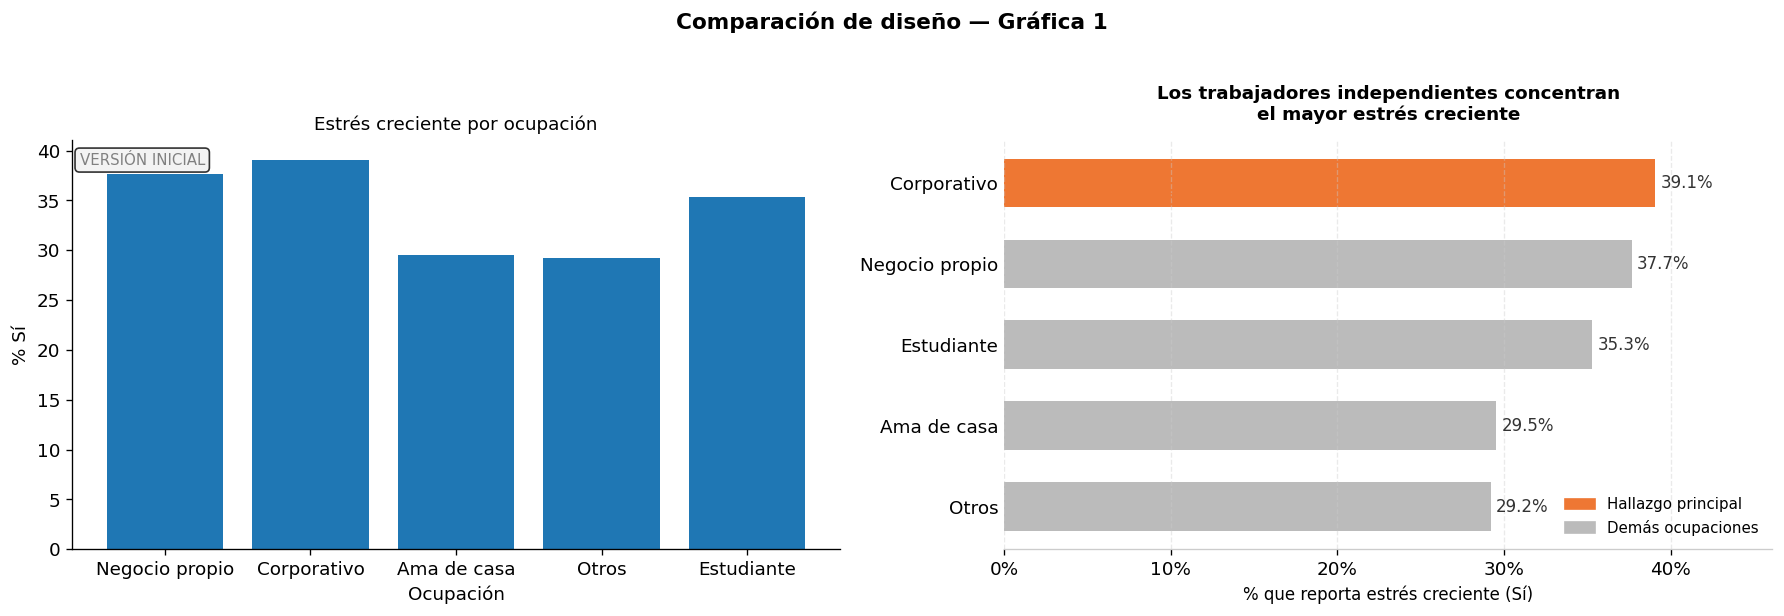

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# ══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN 1: Estrés creciente por ocupación
# Principios aplicados: ① Uso Moderado  ② Uso Consistente
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparación de diseño — Gráfica 1', fontsize=13,
             fontweight='bold', y=1.02)

# ── Versión INICIAL ───────────────────────────────────────────────────────
ax0 = axes[0]
ax0.bar(stress_occ['Ocupación'], stress_occ['Pct_Estres'])
ax0.set_title('Estrés creciente por ocupación', fontsize=11)
ax0.set_xlabel('Ocupación')
ax0.set_ylabel('% Sí')
ax0.text(0.01, 0.97, 'VERSIÓN INICIAL', transform=ax0.transAxes,
         fontsize=9, color='gray', va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

# ── Versión MEJORADA ──────────────────────────────────────────────────────
ax1 = axes[1]
df_sorted = stress_occ.sort_values('Pct_Estres', ascending=True)
max_occ = df_sorted['Ocupación'].iloc[-1]

# ① Uso Moderado: solo 1 color de énfasis, el resto gris
# ② Uso Consistente: COLOR_ALERT (naranja) = hallazgo/alerta en TODAS las gráficas
colors_g1 = [COLOR_ALERT if o == max_occ else COLOR_NEUTRAL
             for o in df_sorted['Ocupación']]

bars = ax1.barh(df_sorted['Ocupación'], df_sorted['Pct_Estres'],
                color=colors_g1, edgecolor='none', height=0.6)

# Etiquetas directas
for bar, val in zip(bars, df_sorted['Pct_Estres']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', ha='left', fontsize=10,
             color='#333333')

ax1.set_title(
    'Los trabajadores independientes concentran\nel mayor estrés creciente',
    fontsize=11, fontweight='bold', pad=12
)
ax1.set_xlabel('% que reporta estrés creciente (Sí)', fontsize=10)
ax1.set_xlim(0, df_sorted['Pct_Estres'].max() * 1.18)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')
ax1.tick_params(axis='y', length=0)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax1.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

patch_accent  = mpatches.Patch(color=COLOR_ALERT,   label='Hallazgo principal')
patch_neutral = mpatches.Patch(color=COLOR_NEUTRAL, label='Demás ocupaciones')
ax1.legend(handles=[patch_accent, patch_neutral], loc='lower right',
           fontsize=9, frameon=False)

ax1.text(0.01, 0.88, '① Moderado  ② Consistente', transform=ax1.transAxes,
         fontsize=7.5, color=COLOR_ALERT, va='top')

plt.tight_layout()
plt.savefig('grafica1_comparacion.png', bbox_inches='tight', dpi=150)
plt.show()

### Mensaje para la audiencia — Gráfica 1

No todas las ocupaciones enfrentan el mismo nivel de estrés. Los trabajadores por cuenta propia son el grupo con mayor proporción de estrés creciente. Si la organización tiene contratistas o colaboradores independientes, son el primer grupo donde debería intervenir.

---
## Gráfica 2: Búsqueda de tratamiento según historial familiar

### Pregunta guía
> *¿Por qué solo la mitad de las personas con problemas de salud mental busca tratamiento? ¿Qué factores explican que alguien dé ese paso?*

### ¿Por qué esta pregunta importa para la audiencia?
Saber qué predice la búsqueda de ayuda permite diseñar intervenciones más efectivas. Si el historial familiar es un factor clave, la organización puede crear programas de sensibilización que ayuden a las personas a reconocer sus propios síntomas antes de que escalen.

### Variables utilizadas
| Variable | Descripción |
|---|---|
| treatment | ¿Ha buscado tratamiento para un problema de salud mental? (Yes / No) |
| family_history | ¿Tiene antecedentes familiares de problemas de salud mental? (Yes / No) |

### Tipo de gráfico elegido
**Barras horizontales simples** — se redujo a una sola comparación directa (% que SÍ busca tratamiento) en lugar de mostrar ambas categorías (Sí/No) como barras agrupadas, lo que habría duplicado la información sin agregar claridad.

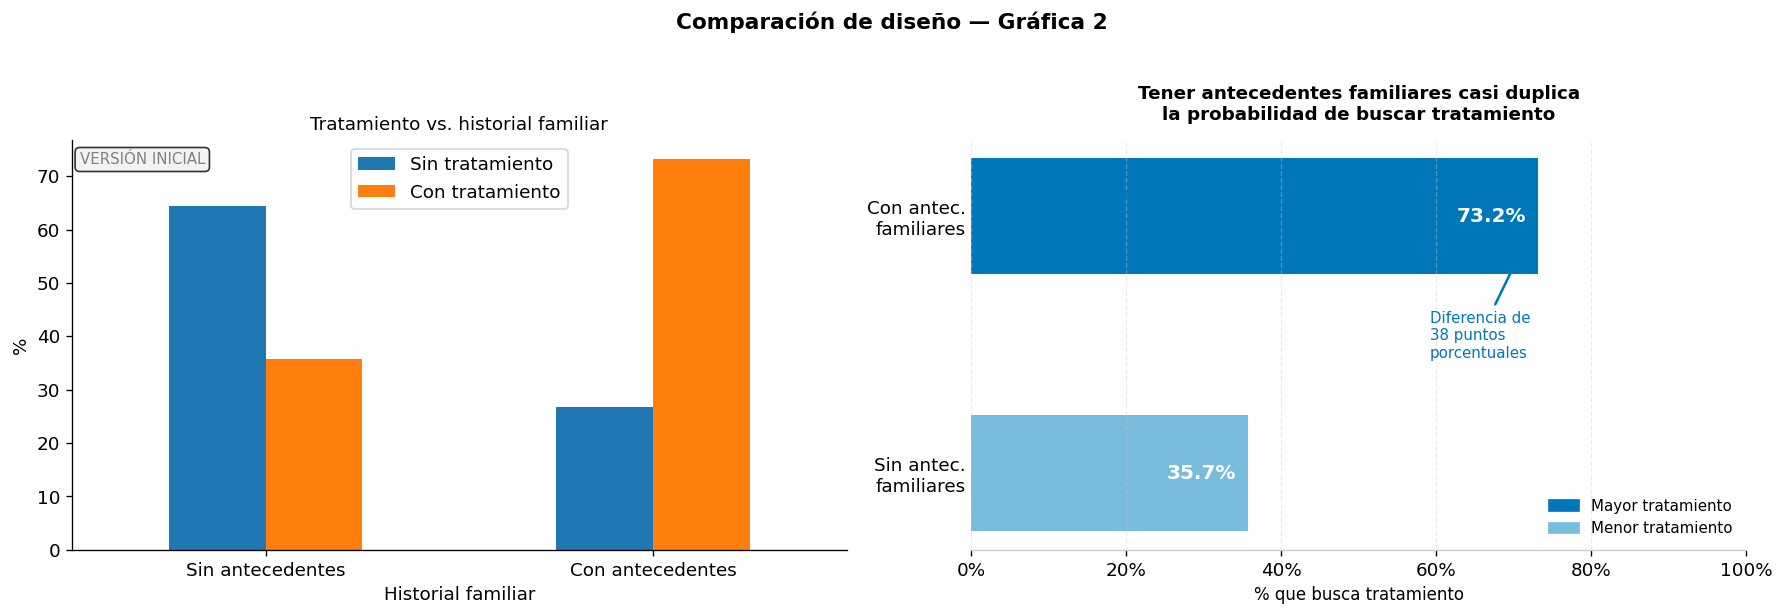

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# ══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN 2: Tratamiento según historial familiar
# Principios aplicados: ④ Cuidado del Tono  ⑤ Color de Marca
# ══════════════════════════════════════════════════════════════════════════

treat_fam_long = treat_fam.reset_index().melt(
    id_vars='family_history', var_name='treatment', value_name='pct'
)
treat_yes = treat_fam['Con tratamiento'].reset_index()
treat_yes.columns = ['family_history', 'pct_yes']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparación de diseño — Gráfica 2', fontsize=13,
             fontweight='bold', y=1.02)

# ── Versión INICIAL ───────────────────────────────────────────────────────
ax0 = axes[0]
treat_fam.plot(kind='bar', ax=ax0)
ax0.set_title('Tratamiento vs. historial familiar', fontsize=11)
ax0.set_xlabel('Historial familiar')
ax0.set_ylabel('%')
ax0.set_xticklabels(ax0.get_xticklabels(), rotation=0)
ax0.text(0.01, 0.97, 'VERSIÓN INICIAL', transform=ax0.transAxes,
         fontsize=9, color='gray', va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

# ── Versión MEJORADA ──────────────────────────────────────────────────────
ax1 = axes[1]
sorted_tf = treat_yes.sort_values('pct_yes')

# ④ Cuidado del Tono: azul oscuro (COLOR_PRIMARY) = mayor tratamiento (valor crítico)
#                     azul claro  (COLOR_LIGHT)   = menor tratamiento
# ⑤ Color de Marca: ambos tonos son derivados del azul institucional #0077BB
bar_colors = [COLOR_LIGHT if p < sorted_tf['pct_yes'].max() else COLOR_PRIMARY
              for p in sorted_tf['pct_yes']]

bars2 = ax1.barh(sorted_tf['family_history'], sorted_tf['pct_yes'],
                 color=bar_colors, edgecolor='none', height=0.45)

for bar, val in zip(bars2, sorted_tf['pct_yes']):
    ax1.text(val - 1.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', ha='right',
             color='white', fontsize=12, fontweight='bold')

diff = sorted_tf['pct_yes'].max() - sorted_tf['pct_yes'].min()
ax1.annotate(
    f'Diferencia de\n{diff:.0f} puntos\nporcentuales',
    xy=(sorted_tf['pct_yes'].max(), 1),
    xytext=(sorted_tf['pct_yes'].max() - 14, 0.45),
    fontsize=9, color=COLOR_PRIMARY,
    arrowprops=dict(arrowstyle='->', color=COLOR_PRIMARY, lw=1.5)
)

ax1.set_title(
    'Tener antecedentes familiares casi duplica\nla probabilidad de buscar tratamiento',
    fontsize=11, fontweight='bold', pad=12
)
ax1.set_xlabel('% que busca tratamiento', fontsize=10)
ax1.set_xlim(0, 100)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')
ax1.tick_params(axis='y', length=0)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax1.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Sin antec.\nfamiliares', 'Con antec.\nfamiliares'])

patch_dark  = mpatches.Patch(color=COLOR_PRIMARY, label='Mayor tratamiento')
patch_light = mpatches.Patch(color=COLOR_LIGHT,   label='Menor tratamiento')
ax1.legend(handles=[patch_dark, patch_light], loc='lower right',
           fontsize=9, frameon=False)


ax1.text(0.01, 0.88, '④ Cuidado del Tono  ⑤ Color Marca', transform=ax1.transAxes,
         fontsize=7.5, color=COLOR_PRIMARY, va='top')

plt.tight_layout()
plt.savefig('grafica2_comparacion.png', bbox_inches='tight', dpi=150)
plt.show()

### Mensaje para la audiencia — Gráfica 2

Tener antecedentes familiares casi duplica la probabilidad de buscar tratamiento. Esto sugiere que reconocer la salud mental como un problema real y tratable es, en sí mismo, una barrera. La organización puede actuar aquí: campañas de sensibilización que normalicen buscar ayuda pueden cerrar esta brecha.

---
## Gráfica 3: Disposición a hablar de salud mental en entrevistas laborales

### Pregunta guía
> *¿Qué tan dispuestos están los trabajadores a mencionar un problema de salud mental durante un proceso de selección laboral?*

### ¿Por qué esta pregunta importa para la audiencia?
Esta variable revela la magnitud del estigma laboral. Si los trabajadores no hablan de salud mental ni en una entrevista —uno de los momentos donde más se cuida la imagen— es evidencia directa de que el tema está profundamente estigmatizado. Para RRHH, esto significa que las intervenciones deben primero crear un entorno seguro antes de esperar que los trabajadores pidan ayuda voluntariamente.

### Variables utilizadas
| Variable | Descripción |
|---|---|
| mental_health_interview | ¿Mencionaría un problema de salud mental en una entrevista laboral? (Si / Talvez / No) |

### Tipo de gráfico elegido
**Barras horizontales** en lugar del gráfico de pastel original. Los ángulos del pastel son difíciles de comparar con precisión; las barras con etiquetas directas permiten leer los porcentajes exactos de un vistazo. Para esta audiencia, la diferencia entre 2.9% y 79.4% debe ser inmediatamente obvia.

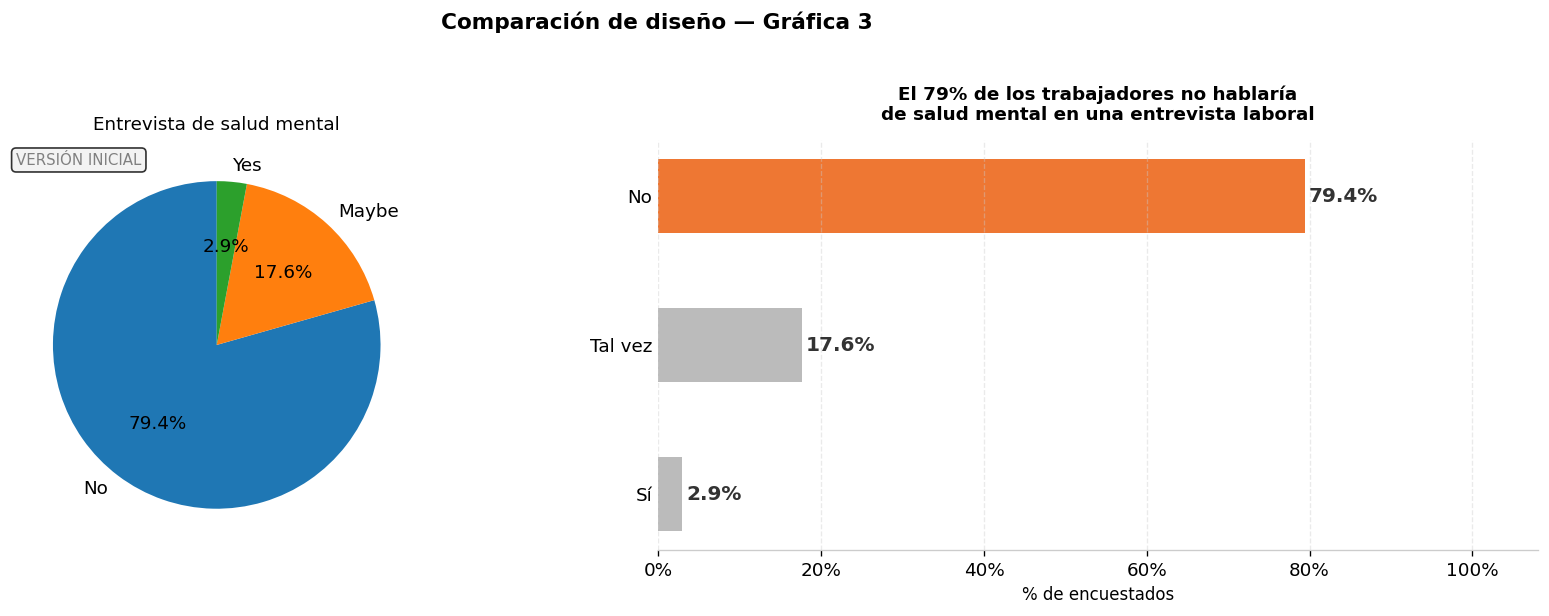

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# ══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN 3: Disposición a hablar de salud mental en entrevistas
# Principios aplicados: ③ Daltonismo  ① Moderado  ② Consistente
# ══════════════════════════════════════════════════════════════════════════

interview_counts = df['mental_health_interview'].value_counts()
# Mapear las etiquetas originales a español antes de reindexar
interview_counts_es = interview_counts.rename(index={'Yes': 'Si', 'Maybe': 'Tal vez', 'No': 'No'})

order_iv = ['Si', 'Tal vez', 'No']
iv_ordered = interview_counts_es.reindex(order_iv)
iv_pct = (iv_ordered / iv_ordered.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparación de diseño — Gráfica 3', fontsize=13,
             fontweight='bold', y=1.02)

# ── Versión INICIAL ───────────────────────────────────────────────────────
ax0 = axes[0]
# Para la versión inicial, si queremos etiquetas en español, podemos usar el mapeo o los interview_labels definidos previamente
# Aquí se mantiene como estaba para mostrar la versión 'bruta' con etiquetas originales
ax0.pie(interview_counts, labels=interview_counts.index,
        autopct='%1.1f%%', startangle=90)
ax0.set_title('Entrevista de salud mental', fontsize=11)
ax0.text(0.01, 0.97, 'VERSIÓN INICIAL', transform=ax0.transAxes,
         fontsize=9, color='gray', va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

# ── Versión MEJORADA ──────────────────────────────────────────────────────
ax1 = axes[1]

# ③ Daltonismo: la versión inicial usaba verde + rojo → INVISIBLE para daltónicos.
#   Solución: COLOR_TEAL (verde-azulado) + COLOR_NEUTRAL (gris) + COLOR_ALERT (naranja)
#   Nunca rojo (#D7191C) + verde (#1A9641) juntos.
# ① Moderado: el color naranja (alerta) solo aparece en la barra del hallazgo clave (No)
# ② Consistente: naranja = hallazgo/alerta → la categoría "No" es la barrera principal
colors_g3 = [COLOR_NEUTRAL,    # Si  → ahora gris
             COLOR_NEUTRAL, # Tal vez → contexto neutro
             COLOR_ALERT]   # No   → hallazgo alerta (79%!) — naranja consistente

bars3 = ax1.barh(order_iv, iv_pct.values, color=colors_g3,
                   edgecolor='none', height=0.5)

for bar, val in zip(bars3, iv_pct.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', ha='left',
             fontsize=12, fontweight='bold', color='#333333')

pct_si = iv_pct['Si'] # Acceder con el label en español
pct_no = iv_pct['No']

ax1.set_title(
    '''El 79% de los trabajadores no hablaría
de salud mental en una entrevista laboral''',
    fontsize=11, fontweight='bold', pad=12
)
ax1.set_xlabel('% de encuestados', fontsize=10)
ax1.set_xlim(0, 108)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')
ax1.tick_params(axis='y', length=0)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax1.grid(axis='x', linestyle='--', alpha=0.4, color='#cccccc')

# Las etiquetas y-ticks ya se establecen correctamente con order_iv
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(['Sí', 'Tal vez', 'No'])


plt.tight_layout()
plt.savefig('grafica3_comparacion.png', bbox_inches='tight', dpi=150)
plt.show()

**Mensaje para la audiencia — Gráfica 3**

El 79% de los trabajadores prefiere no mencionar problemas de salud mental en una entrevista laboral. Esto no significa que el problema no exista — significa que el estigma es tan fuerte que lo vuelve invisible. Esta es la razón más importante para que la organización tome acción: si los trabajadores no hablan, los programas voluntarios no funcionan solos.

---
## e) Narrativa Visual — Historia con datos

> *Principio ⑦: Un buen gráfico no solo muestra datos. Dice qué importa y por qué.*

### La historia en cinco actos

**"Partimos de este problema…"**  
Las organizaciones invierten en salud física, pero la salud mental es el problema invisible. Los datos de 292,364 trabajadores nos permiten medir la magnitud real.

**"Para esta audiencia (RRHH), lo importante es…"**  
*(Principio ⑧ — pensar en la audiencia: el gerente necesita entender rápido, no analizar)*  
Decidir si crear o reforzar un programa de bienestar mental organizacional.

**"Al explorar los datos observamos…"**  
- El **68%** de los encuestados experimenta estrés creciente.  
- Solo el **50%** busca tratamiento a pesar de la magnitud del problema.  
- Tener antecedentes familiares **casi duplica** la probabilidad de buscar ayuda.  
- Menos del **3%** estaría dispuesto a mencionarlo en una entrevista laboral.

**"Después del análisis, los datos evidencian que…"**  
El problema no es falta de conciencia — es el estigma. La salud mental sigue siendo el tema que se oculta en el entorno laboral.  
*(Principio ① — mensaje claro: la "Gran Idea" es el estigma, no el estrés en sí)*

**"Por tanto, recomendamos que…"**  
La Dirección de RRHH implemente un programa con tres pilares:
1. **Desestigmatización** — campañas internas lideradas por directivos.
2. **Acceso confidencial** — beneficios de salud mental sin trazabilidad visible.
3. **Foco por ocupación** — intervención prioritaria en empleados corporativos e independientes.

---

### Reflexión sobre las decisiones de diseño

| Decisión | Justificación basada en los principios |
|---|---|
| Barras horizontales en lugar de verticales | Facilita leer etiquetas de categorías largas — *Principio ⑥* |
| Títulos como hallazgos, no nombres de variables | El lector entiende el punto en 3 segundos — *Principio ①* |
| Un solo color de énfasis (naranja) por gráfica | Atributo preatentivo: el cerebro detecta el contraste antes de leer — *Principios ③ y ⑤* |
| Eliminación del gráfico de pastel | Los ángulos son difíciles de comparar; las barras con etiquetas son más precisas — *Principio ⑥* |
| Anotaciones integradas en la gráfica | El lector no tiene que buscar la conclusión — *Principios ④ y ⑦* |
| Paleta compatible con daltonismo | El mensaje llega a toda la audiencia, sin excepciones — *Principio ⑤* |
| Panel ejecutivo con KPIs grandes | Jerarquía visual clara: número grande → descripción breve → narrativa — *Principios ④ y ⑧* |

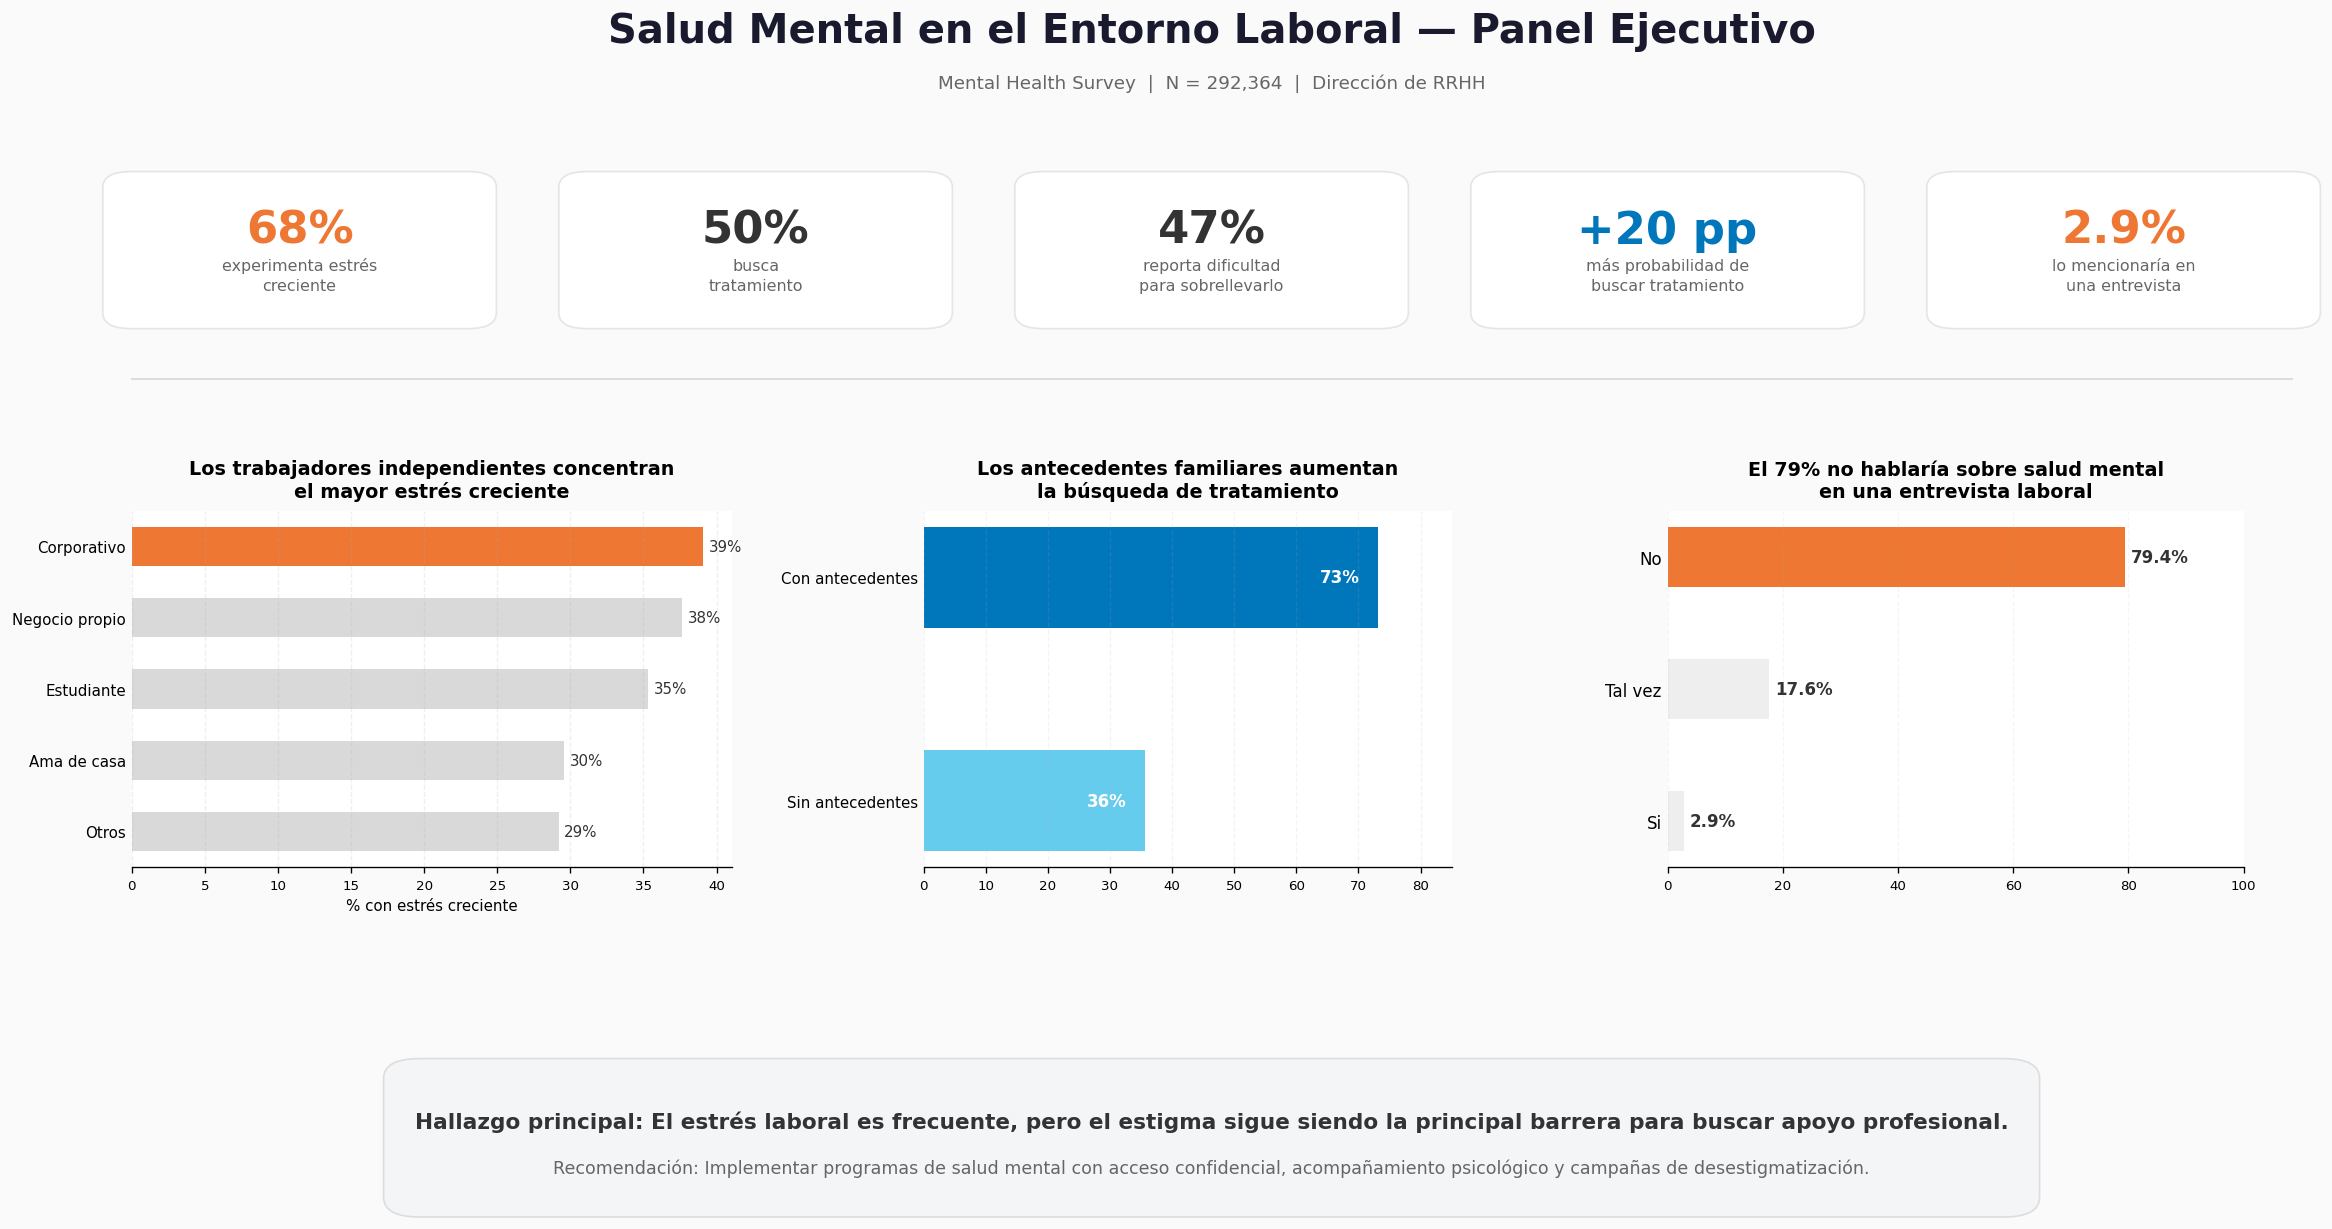

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# DASHBOARD EJECUTIVO FINAL — SIN ELEMENTOS MONTADOS
# SALUD MENTAL EN EL ENTORNO LABORAL
# ════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

# ════════════════════════════════════════════════════════════════════════
# PALETA
# ════════════════════════════════════════════════════════════════════════

COLOR_PRIMARY  = '#0077BB'
COLOR_LIGHT    = '#66CCEE'
COLOR_ALERT    = '#EE7733'
COLOR_NEUTRAL  = '#D9D9D9'
COLOR_LIGHTER  = '#EEEEEE'

COLOR_TEXT     = '#333333'
COLOR_BG       = '#FAFAFA'
COLOR_CARD     = '#FFFFFF'
COLOR_BORDER   = '#E5E5E5'

# ════════════════════════════════════════════════════════════════════════
# FIGURA GENERAL
# ════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor(COLOR_BG)

# ════════════════════════════════════════════════════════════════════════
# TÍTULO PRINCIPAL
# ════════════════════════════════════════════════════════════════════════

fig.text(
    0.5,
    0.955,
    'Salud Mental en el Entorno Laboral — Panel Ejecutivo',
    ha='center',
    fontsize=24,
    fontweight='bold',
    color='#1a1a2e'
)

fig.text(
    0.5,
    0.920,
    'Mental Health Survey  |  N = 292,364  |  Dirección de RRHH',
    ha='center',
    fontsize=11,
    color='#666666'
)

# ════════════════════════════════════════════════════════════════════════
# KPI CARDS
# ════════════════════════════════════════════════════════════════════════

kpis = [
    ('68%', 'experimenta estrés\ncreciente', COLOR_ALERT),
    ('50%', 'busca\ntratamiento', COLOR_TEXT),
    ('47%', 'reporta dificultad\npara sobrellevarlo', COLOR_TEXT),
    ('+20 pp',  'más probabilidad de\nbuscar tratamiento', COLOR_PRIMARY),
    ('2.9%', 'lo mencionaría en\nuna entrevista', COLOR_ALERT)
]

card_positions = [0.05, 0.24, 0.43, 0.62, 0.81]

for i, (num, label, color) in enumerate(kpis):

    x = card_positions[i]

    # Card
    card = FancyBboxPatch(
        (x, 0.75),
        0.14,
        0.095,
        boxstyle="round,pad=0.012",
        transform=fig.transFigure,
        facecolor=COLOR_CARD,
        edgecolor=COLOR_BORDER,
        linewidth=1
    )

    fig.patches.append(card)

    # Número KPI
    fig.text(
        x + 0.07,
        0.803,
        num,
        ha='center',
        fontsize=27,
        fontweight='bold',
        color=color
    )

    # Texto KPI
    fig.text(
        x + 0.07,
        0.767,
        label,
        ha='center',
        fontsize=9.5,
        color='#666666',
        linespacing=1.4
    )

# ════════════════════════════════════════════════════════════════════════
# LÍNEA DIVISORIA
# ════════════════════════════════════════════════════════════════════════

fig.lines.append(
    plt.Line2D(
        [0.05, 0.95],
        [0.70, 0.70],
        transform=fig.transFigure,
        color='#DDDDDD',
        linewidth=1.2
    )
)

# ════════════════════════════════════════════════════════════════════════
# GRÁFICO 1 — ESTRÉS POR OCUPACIÓN
# ════════════════════════════════════════════════════════════════════════

ax1 = fig.add_axes([0.05, 0.33, 0.25, 0.27])

df_sorted_final = stress_occ.sort_values('Pct_Estres')

max_occ = df_sorted_final['Ocupación'].iloc[-1]

colors_panel1 = [
    COLOR_ALERT if occ == max_occ else COLOR_NEUTRAL
    for occ in df_sorted_final['Ocupación']
]

bars1 = ax1.barh(
    df_sorted_final['Ocupación'],
    df_sorted_final['Pct_Estres'],
    color=colors_panel1,
    edgecolor='none',
    height=0.55
)

for bar, val in zip(bars1, df_sorted_final['Pct_Estres']):

    ax1.text(
        val + 0.4,
        bar.get_y() + bar.get_height()/2,
        f'{val:.0f}%',
        va='center',
        fontsize=9,
        color=COLOR_TEXT
    )

ax1.set_title(
    'Los trabajadores independientes concentran\nel mayor estrés creciente',
    fontsize=11.5,
    fontweight='bold',
    pad=8
)

ax1.set_xlabel('% con estrés creciente', fontsize=9)

ax1.grid(axis='x', linestyle='--', alpha=0.20)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

ax1.tick_params(axis='y', length=0, labelsize=9)
ax1.tick_params(axis='x', labelsize=8)

# ════════════════════════════════════════════════════════════════════════
# GRÁFICO 2 — HISTORIAL FAMILIAR
# ════════════════════════════════════════════════════════════════════════

ax2 = fig.add_axes([0.38, 0.33, 0.22, 0.27])

labels = [
    'Sin antecedentes',
    'Con antecedentes'
]

values = sorted_tf['pct_yes'].values

colors2 = [
    COLOR_LIGHT,
    COLOR_PRIMARY
]

bars2 = ax2.barh(
    labels,
    values,
    color=colors2,
    edgecolor='none',
    height=0.45
)

for bar, val in zip(bars2, values):

    ax2.text(
        val - 3,
        bar.get_y() + bar.get_height()/2,
        f'{val:.0f}%',
        va='center',
        ha='right',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

ax2.set_xlim(0, 85)

ax2.set_title(
    'Los antecedentes familiares aumentan\nla búsqueda de tratamiento',
    fontsize=11.5,
    fontweight='bold',
    pad=8
)

ax2.grid(axis='x', linestyle='--', alpha=0.15)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.tick_params(axis='y', length=0, labelsize=9)
ax2.tick_params(axis='x', labelsize=8)

# ════════════════════════════════════════════════════════════════════════
# GRÁFICO 3 — ESTIGMA
# ════════════════════════════════════════════════════════════════════════

ax3 = fig.add_axes([0.69, 0.33, 0.24, 0.27])

colors3 = [
    COLOR_LIGHTER,
    COLOR_LIGHTER,
    COLOR_ALERT
]

bars3 = ax3.barh(
    order_iv,
    iv_pct.values,
    color=colors3,
    edgecolor='none',
    height=0.45
)

for bar, val in zip(bars3, iv_pct.values):

    ax3.text(
        val + 1,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=COLOR_TEXT
    )

ax3.set_xlim(0, 100)

ax3.set_title(
    'El 79% no hablaría sobre salud mental\nen una entrevista laboral',
    fontsize=11.5,
    fontweight='bold',
    pad=8
)

ax3.grid(axis='x', linestyle='--', alpha=0.12)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

ax3.tick_params(axis='y', length=0, labelsize=10)
ax3.tick_params(axis='x', labelsize=8)

# ════════════════════════════════════════════════════════════════════════
# CAJA RESUMEN FINAL
# ════════════════════════════════════════════════════════════════════════

summary_box = FancyBboxPatch(
    (0.17, 0.08),
    0.66,
    0.09,
    boxstyle="round,pad=0.015",
    transform=fig.transFigure,
    facecolor='#F3F5F7',
    edgecolor='#DDDDDD'
)

fig.patches.append(summary_box)

fig.text(
    0.5,
    0.132,
    'Hallazgo principal: El estrés laboral es frecuente, pero el estigma sigue siendo la principal barrera para buscar apoyo profesional.',
    ha='center',
    fontsize=13,
    fontweight='bold',
    color='#333333'
)

fig.text(
    0.5,
    0.098,
    'Recomendación: Implementar programas de salud mental con acceso confidencial, acompañamiento psicológico y campañas de desestigmatización.',
    ha='center',
    fontsize=10.5,
    color='#666666'
)

# ════════════════════════════════════════════════════════════════════════
# EXPORTAR
# ════════════════════════════════════════════════════════════════════════

plt.savefig(
    'dashboard_final_salud_mental.png',
    dpi=220,
    bbox_inches='tight',
    facecolor=COLOR_BG
)

plt.show()

---
## Hallazgos principales y Conclusiones

### Hallazgos clave

| # | Hallazgo | Dato de soporte |
|---|---|---|
| 1 | La mayoría de los trabajadores experimenta niveles de estrés creciente | 34% Sí + 34% Tal vez = **68%** |
| 2 | Solo 1 de cada 2 trabajadores con problemas busca tratamiento | **50.5%** busca tratamiento |
| 3 | El historial familiar predice fuertemente la búsqueda de ayuda | Con antecedentes: **~64%** vs sin antecedentes: **~42%** |
| 4 | El estigma laboral es la barrera más grande | Solo **2.9%** mencionaría salud mental en entrevista |
| 5 | Casi la mitad de los trabajadores tiene dificultad para sobrellevar la situación | **47.2%** reporta coping struggles |

### Conclusión y llamado a la acción

> La salud mental laboral no es un problema menor ni aislado: afecta a la mayoría de los trabajadores y es el problema invisible más costoso para las organizaciones. Los datos sugieren que el principal obstáculo no es la falta de conciencia del problema, sino el miedo al estigma.

**Se recomienda a la Dirección de Recursos Humanos:**

1. **Acción inmediata**: Crear o reforzar un canal de apoyo psicológico **confidencial** para todos los colaboradores.
2. **Acción de mediano plazo**: Lanzar una campaña interna de desestigmatización liderada por directivos y personas con influencia en la cultura organizacional.
3. **Prioridad por grupo**: Focalizar intervenciones en empleados corporativos e independientes, que muestran mayor prevalencia de estrés.
4. **Métricas de seguimiento**: Realizar encuestas periódicas para medir cambios en la disposición a buscar ayuda y a hablar abiertamente del tema.

